In [19]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [20]:
titanic = sns.load_dataset("titanic")
# titanic.head(50)

In [5]:
# titanic = sns.load_dataset("penguins")
# titanic.head()

In [6]:
# print(titanic['species'].unique())
# print(titanic['island'].unique())

In [7]:
# titanic.isnull().sum()

In [8]:
# titanic['sex'].fillna('Unknown', inplace=True)
# titanic.isnull().sum()
# # df['sex'].fillna(df['sex'].mode().iloc[0], inplace=True)


In [9]:
# titanic.head(10)

In [36]:
titanic = titanic[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
titanic = titanic.dropna()  # drop rows with missing values
# df['age'] = df['age'].fillna(df['age'].mean())

titanic_encoded = pd.get_dummies(titanic, columns=['sex', 'embarked'], drop_first=True)
#print(titanic_encoded)
# Features and target
features = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']
X = titanic_encoded[features]
y = titanic_encoded['survived']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42,stratify=y)

In [37]:
#feature Scaling  
from sklearn.preprocessing import StandardScaler    
st_x= StandardScaler()    
X_train= st_x.fit_transform(X_train)    
X_test= st_x.transform(X_test) 

In [38]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
# #Fitting K-NN classifier to the training set  
# from sklearn.neighbors import KNeighborsClassifier  
# classifier= KNeighborsClassifier()  
# classifier.fit(X_train, y_train)  


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
#Predicting the test set result  
y_pred= rf.predict(X_test)  
y_pred

array([1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0], dtype=int64)

In [41]:
#Creating the Confusion matrix  
from sklearn.metrics import confusion_matrix  
cm= confusion_matrix(y_test, y_pred)  
cm

array([[85, 21],
       [21, 51]], dtype=int64)

In [42]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7640449438202247


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)


Best parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Best CV score: 0.8072297654734614


In [17]:
y_pred1 = grid.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred1)

print("Test Accuracy:", test_accuracy)


Test Accuracy: 0.7752808988764045


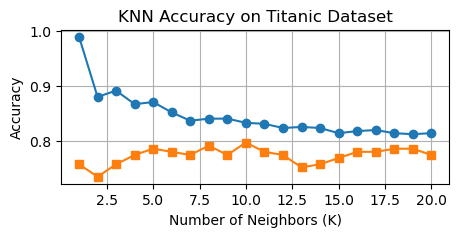

In [18]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

train_acc = []
test_acc = []

k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))

plt.figure(figsize=(5, 2))
plt.plot(k_values, train_acc, marker='o', label='Train Accuracy')
plt.plot(k_values, test_acc, marker='s', label='Test Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy on Titanic Dataset')
# plt.legend()
plt.grid(True)
plt.show()
